In [ ]:
import numpy as np
import pandas as pd
import sklearn.model_selection
import argparse, os, glob, re, warnings, shutil, pysam, vcf, subprocess
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from Bio import Seq, SeqIO
import scipy.stats as st

df_isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv")

df_assemblies = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")
df_ASM_QC = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/hybridASM_QC.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) == float:
            df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
        else:
            df_trust_patients.loc[i, 'Lineage'] = str(row['Lineage'])
     
print(df_trust_patients.Lineage.value_counts())
            
F2_max = 0.03
h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

genomic_data_dir = "/n/data1/hms/dbmi/farhat/rollingDB/genomic_data"

LinToColor_Dict = {"1": "#DF83AC",
                   "2": "#7098CB",
                   "3": "#815D9F",
                   "4": "#E76956",
                  }

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    insertion_seqs_phages_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)

# 0. Rv3433c GC Content because the coverage drops off slowly, rather than abruptly

In [5]:
Rv3433c_seq = str(h37Rv_seq.seq[3851792-1:3853213])
print(len(Rv3433c_seq))

base_counts = dict(zip(np.unique(list(Rv3433c_seq), return_counts=True)[0], np.unique(list(Rv3433c_seq), return_counts=True)[1]))

(base_counts['C'] + base_counts['G']) / (np.array(list(base_counts.values())).sum())

1422


0.7475386779184248

\
.    

In [11]:
base_counts = dict(zip(np.unique(list(h37Rv_seq), return_counts=True)[0], np.unique(list(h37Rv_seq), return_counts=True)[1]))

(base_counts['C'] + base_counts['G']) / (np.array(list(base_counts.values())).sum())

0.6561466628826449

# 1. Coverage Statistics and Lengths of the Hybrid Assemblies

In [2]:
# drop duplicates because some ASMs have been matched with multiple Illumina samples for the purposes of making the ground truth set
df_assemblies_QC = df_assemblies.merge(df_ASM_QC, on=['ASM', 'PacBio_FQ_PATH']).drop_duplicates(subset='ASM')

assert len(df_assemblies_QC.query("Flye_Coll2014 != Flye_PP_Coll2014")) == 0
assert len(df_assemblies_QC.query("Flye_Coll2014 != Illumina_Coll2014")) == 0

df_assemblies_QC['Lineage'] = df_assemblies_QC['Flye_PP_Coll2014'].str.split('.').str[0]

len(df_assemblies_QC)

154

In [ ]:
ref_genome="/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/references/ref_genome/H37Rv_NC_000962.3.fna"

bcftools mpileup haplotype_1.bam -q 1 -Q 10 -d 200 -f $ref_genome -a FMT/AD -Ou \
  | bcftools call --ploidy 1 -A -m --prior 1e-2 -C alleles -T /home/sak0914/MtbLongitudinalDiversity/direct_sputum/tbtyper_targets_Chromosome.tsv -Ou \
  | bcftools annotate -x INFO,^FORMAT/GT,^FORMAT/AD -Oz -o haplotype_1.vcf.gz

bcftools mpileup haplotype_2.bam -q 1 -Q 10 -d 200 -f $ref_genome -a FMT/AD -Ou \
  | bcftools call --ploidy 1 -A -m --prior 1e-2 -C alleles -T /home/sak0914/MtbLongitudinalDiversity/direct_sputum/tbtyper_targets_Chromosome.tsv -Ou \
  | bcftools annotate -x INFO,^FORMAT/GT,^FORMAT/AD -Oz -o haplotype_2.vcf.gz

In [16]:
tbtyper = pd.read_csv("~/MtbLongitudinalDiversity/direct_sputum/tbtyper_targets.tsv", sep='\t', header=None)

In [17]:
tbtyper[0] = 'Chromosome'

In [27]:
# tbtyper.to_csv("~/MtbLongitudinalDiversity/direct_sputum/tbtyper_targets_Chromosome.tsv", sep='\t', header=None, index=False)

In [18]:
tbtyper_culture = pd.read_csv("~/tbtyper_culture.csv")

In [19]:
tbtyper_culture

,SampleID,mix_phylotypes,mix_props,n_phy,defaultParams
0,MFS-1,2.2.M1.1,1.0,1,1
1,MFS-10,4.3.2.1,1.0,1,1
2,MFS-100,4.4.1.1,1.0,1,1
3,MFS-101,4.4.1.1,1.0,1,1
4,MFS-102,4.1.1.3,1.0,1,1
...,...,...,...,...,...
762,MFS-95,4.1.1.3,1.0,1,1
763,MFS-96,4.1.1.3,1.0,1,1
764,MFS-97,2.2.M1.1,1.0,1,1
765,MFS-98,4.1.1.3,1.0,1,1


In [20]:
df_ASM_QC_tbtyper = df_ASM_QC.merge(tbtyper_culture, left_on=['Illumina_ID'], right_on='SampleID')

In [21]:
set(df_ASM_QC.Original_ID) - set(df_ASM_QC_tbtyper.Original_ID)

set()

In [22]:
df_ASM_QC_tbtyper.query("Original_ID=='S0305-01'")

,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,ASM,PacBio_FQ_PATH,SampleID,mix_phylotypes,mix_props,n_phy,defaultParams
140,T0305,S0305-01,4,4389416.0,248,4.3.2,4.3.2,36,MFS-313,MFS-313,0.43681,"2.2.1.1,4.3.2.1",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-313,"2.2.M1.1,4.3.2.1","0.4235,0.5765",2,1


In [ ]:
longcallD call -t1 $ref_genome S0066-01.bam -s --hifi -b ../bam_2/S0066-01.bam > ../bam_2/S0066-01.vcf

In [52]:
df_ASM_QC_tbtyper.query("n_phy > 1")[['Original_ID', 'mix_phylotypes', 'mix_props']]

,Original_ID,mix_phylotypes,mix_props
25,S0066-01,"2.2.M1.1,4.3.2.1","0.8965,0.1035"
29,S0072-01,"4.1.2.1,4.8","0.5892,0.4108"
37,S0087-01,"4.1.2.1,4.8","0.5669,0.4331"
69,S0167-01,"2.2.M2.2,4.1.1.3","0.824,0.176"
70,S0167-04,"2.2.M2.2,4.1.1.3","0.7425,0.2575"
85,S0198-02,"2.2.M1.1,4.4.1.1","0.8929,0.1071"
89,S0204-01,"2.2.M4.4,3.1.1.1","0.8577,0.1423"
90,S0204-08,"2.2.M4.4,3.1.1.1","0.6952,0.3048"
114,S0252-01,"2.2.M1.1,4.1.1.3,4.4.1.1","0.4991,0.4882,0.0127"
140,S0305-01,"2.2.M1.1,4.3.2.1","0.4235,0.5765"


In [54]:
df_ASM_QC_tbtyper.query("Original_ID in ['S0072-01', 'S0087-01', 'S0167-04', 'S0204-08', 'S0252-01', 'S0305-01', 'S0311-01', 'S0391-01']").to_csv("../haplotype_phasing/LR_multiple_tbtyper_lineages.csv", index=False)

In [49]:
df_ASM_QC_tbtyper.query("n_phy > 1").to_csv("../haplotype_phasing/LR_multiple_tbtyper_lineages.csv", index=False)

In [57]:
df_ASM_QC_tbtyper.query("Original_ID=='S0305-01'").to_csv("../haplotype_phasing/LR_multiple_tbtyper_lineages.csv", index=False)

In [53]:
df_ASM_QC_tbtyper.query("n_phy > 1")

,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,ASM,PacBio_FQ_PATH,SampleID,mix_phylotypes,mix_props,n_phy,defaultParams
25,T0066,S0066-01,2,NaN,125,2.2.1.1,2.2.1.1,2,MFS-209,MFS-39,0.110925,2.2.1.1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-39,"2.2.M1.1,4.3.2.1","0.8965,0.1035",2,1
29,T0072,S0072-01,6,NaN,12,4.1.2,4.1.2,30,MFS-350,MFS-350,0.408194,"4.1.2.1,4.8",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-350,"4.1.2.1,4.8","0.5892,0.4108",2,1
37,T0087,S0087-01,5,NaN,15,"4.1.2.1,4.8","4.1.2.1,4.8",50,MFS-353,MFS-353,0.415768,"4.1.2.1,4.8",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-353,"4.1.2.1,4.8","0.5669,0.4331",2,1
69,T0167,S0167-01,3,NaN,50,2.2.1,2.2.1,4,MFS-84,MFS-84,0.177757,2.2.1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-84,"2.2.M2.2,4.1.1.3","0.824,0.176",2,1
70,T0167,S0167-04,8,NaN,49,2.2.1,2.2.1,0,MFS-85,MFS-85,0.259418,"2.2.1,4.1.1.3",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-85,"2.2.M2.2,4.1.1.3","0.7425,0.2575",2,1
85,T0198,S0198-02,1,4416530.0,173,2.2.1.1,2.2.1.1,0,MFS-377,MFS-377,0.108434,2.2.1.1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-377,"2.2.M1.1,4.4.1.1","0.8929,0.1071",2,1
89,T0204,S0204-01,2,NaN,21,2.2.1,2.2.1,4,MFS-630,MFS-630,0.147559,2.2.1,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-630,"2.2.M4.4,3.1.1.1","0.8577,0.1423",2,1
90,T0204,S0204-08,15,NaN,9,"2.2.1,4","2.2.1,4",103,MFS-631,MFS-631,0.314259,"2.2.1,3.1.1",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-631,"2.2.M4.4,3.1.1.1","0.6952,0.3048",2,1
114,T0252,S0252-01,14,NaN,44,2.2.1.1,2.2.1.1,52,MFS-168,MFS-168,0.477297,"2.2.1.1,4.1.1.3",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-168,"2.2.M1.1,4.1.1.3,4.4.1.1","0.4991,0.4882,0.0127",3,1
140,T0305,S0305-01,4,4389416.0,248,4.3.2,4.3.2,36,MFS-313,MFS-313,0.436810,"2.2.1.1,4.3.2.1",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-313,"2.2.M1.1,4.3.2.1","0.4235,0.5765",2,1


In [22]:
df_ASM_QC.query("Illumina_ID=='MFS-313'")#.PacBio_FQ_PATH.values[0]

,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,ASM,PacBio_FQ_PATH
140,T0305,S0305-01,4,4389416.0,248,4.3.2,4.3.2,36,MFS-313,MFS-313,0.43681,"2.2.1.1,4.3.2.1",/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...


In [121]:
df_assemblies_QC.Lineage.value_counts()

Lineage
2    90
4    57
3     6
1     1
Name: count, dtype: int64

In [22]:
df_assemblies_QC.circContigLength.min(), df_assemblies_QC.Flye_Cov.median(), df_assemblies_QC.Flye_Cov.mean()

(4364836.0, 89.5, 99.17532467532467)

In [23]:
df_assemblies_QC.Flye_Cov.min(), df_assemblies_QC.Flye_Cov.max()

(14, 295)

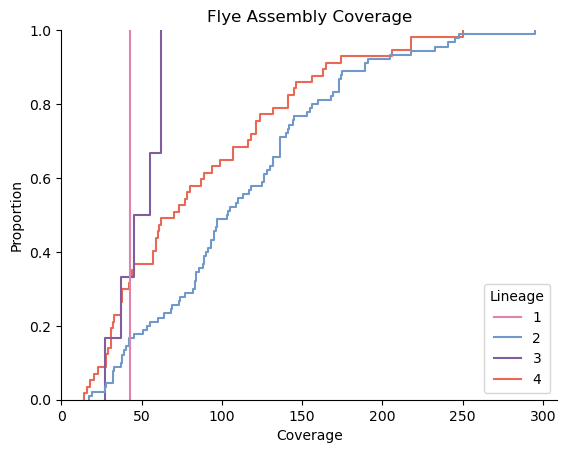

In [5]:
ax = sns.ecdfplot(
    data=df_assemblies_QC,
    x='Flye_Cov',
    hue='Lineage',
    palette=LinToColor_Dict,
    hue_order=np.sort(df_assemblies_QC['Lineage'].unique())
)

# Get the existing legend created by seaborn
sns.move_legend(ax, "lower right")

plt.title("Flye Assembly Coverage")
plt.xlabel('Coverage')

sns.despine()
plt.savefig("./figures/flye_coverage.svg", bbox_inches='tight')

In [6]:
df_assemblies_QC.query("Lineage=='1'")

,SampleID,ASM,PacBio_FQ_PATH,ASM_SampleID,pid,Original_ID,numContigs,circContigLength,Flye_Cov,Flye_Coll2014,Flye_PP_Coll2014,NumPilonChanges,PacBio_ID,Illumina_ID,Illumina_F2,Illumina_Coll2014,Lineage
24,MFS-520,/n/data1/hms/dbmi/farhat/rollingDB/TRUST/PacBi...,/n/data1/hms/dbmi/farhat/fastq_db/TRUST_PacBio...,MFS-520,T0017,S0017-01,1,4429510.0,43,1.1.2,1.1.2,0,MFS-520,MFS-520,0.019246,1.1.2,1


# 2. Selecting the F2 threshold: Show number of low-AF variants (before LMM) vs. F2

In [122]:
all_samples = os.listdir(H37Rv_ref_dir)
len(all_samples)

767

In [123]:
len(df_trust_patients.query("SampleID in @all_samples & F2 <= @F2_max"))

738

In [4]:
df_trust_patients.query("SampleID in @all_samples & F2 <= @F2_max").Lineage.value_counts()

Lineage
2    366
4    323
3     48
1      1
Name: count, dtype: int64

In [6]:
df_trust_patients.query("SampleID in @all_samples").pid.nunique()

424

In [7]:
df_lowAF_SNPs = []

for i, sample in enumerate(all_samples):
    
    df = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/lowAF_SNPs.csv")

    df = df.query("AF >= 0.05 & AF <= 0.95 & POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df['SampleID'] = sample
    
    df_lowAF_SNPs.append(df.query("REF.str.len() == ALT.str.len()"))

df_lowAF_SNPs = pd.concat(df_lowAF_SNPs).drop_duplicates(['SampleID', 'POS', 'REF', 'ALT'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2']], how='left')
df_lowAF_SNPs['Region'] = df_lowAF_SNPs['POS'].map(h37Rv_coords_dict)

df_lowAF_SNPs_summary = pd.DataFrame(df_lowAF_SNPs.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumSNPs'}))

df_lowAF_SNPs_summary = pd.concat([df_lowAF_SNPs_summary,
                                   df_trust_patients.dropna(subset='Lineage').query("SampleID not in @df_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2']]
                                ])

df_lowAF_SNPs_summary['NumSNPs'] = df_lowAF_SNPs_summary['NumSNPs'].fillna(0).astype(int)

In [8]:
df_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'].sum()

4307

In [29]:
model_dir = "../lowAF_variant_calling/variantDetector/unmixed_only"

df_train = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv")
df_validation = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")

print(len(df_train) + len(df_validation), len(df_validation))

4307 3361


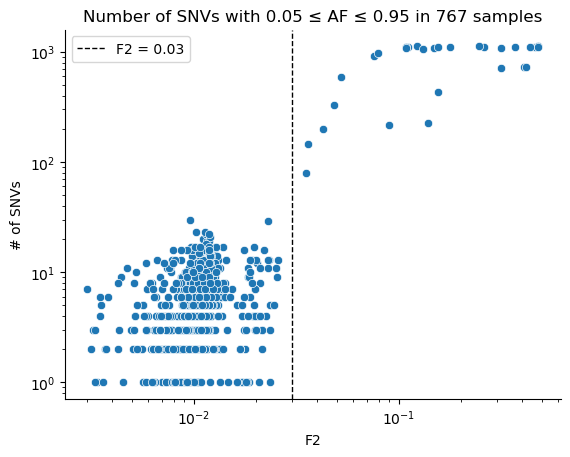

In [32]:
sns.scatterplot(data=df_lowAF_SNPs_summary,
                x='F2',
                y='NumSNPs',
               )

plt.ylabel('# of SNVs')
plt.title(f'Number of SNVs with 0.05 ≤ AF ≤ 0.95 in {df_lowAF_SNPs_summary.SampleID.nunique()} samples')

plt.xscale('log')
plt.yscale('log')

plt.axvline(F2_max, linestyle='--', color='black', linewidth=1, label=f'F2 = {F2_max}')
plt.legend()

sns.despine()
plt.savefig("./figures/lowAF_SNVs_vs_F2_pre_LMM.svg", bbox_inches='tight')

In [33]:
df_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts().head(10)

Region
Rv3433c    490
Rv2082     394
Rv2319c    368
uspC       234
pks15      145
ltp4        71
mmpS1       68
cyp138      58
Rv2081c     58
Rv1637c     46
Name: count, dtype: int64

In [5]:
len(df_lowAF_SNPs.query("F2 <= @F2_max"))

4331

In [11]:
len(df_validation)

3385

In [34]:
df_validation.pred_class.value_counts()

pred_class
1    2048
0    1313
Name: count, dtype: int64

In [35]:
df_validation.pred_class.mean()

0.6093424576019042

In [301]:
df_lowAF_SNPs.query("Region=='Rv2319c'")[['SampleID', 'POS', 'AF', 'AO', 'DP']].POS.unique()

array([2592310, 2591982, 2592270, 2592579], dtype=object)

# 3. Number of low-AF SNVs per Hybrid Assembly

In [36]:
ground_truth_samples = os.listdir(personal_ref_dir)
len(ground_truth_samples)

179

In [113]:
len(set(all_samples) - set(ground_truth_samples))

588

In [115]:
len(all_samples), len(ground_truth_samples)

(767, 179)

In [116]:
738-172

566

In [37]:
df_ground_truth_lowAF_SNPs = []

for i, sample in enumerate(ground_truth_samples):
    
    df = pd.read_csv(f"{personal_ref_dir}/{sample}/lowAF_comparison/ground_truth.csv")

    df = df.query("AF >= 0.05 & AF <= 0.95 & POS not in @insertion_seqs_phages_pos & POS not in @rRNA_pos")
    df['SampleID'] = sample
    
    df_ground_truth_lowAF_SNPs.append(df.query("REF.str.len() == ALT.str.len()"))

df_ground_truth_lowAF_SNPs = pd.concat(df_ground_truth_lowAF_SNPs).drop_duplicates(['SampleID', 'POS', 'REF', 'ALT'], keep='last').merge(df_trust_patients[['pid', 'SampleID', 'F2']], how='left')
df_ground_truth_lowAF_SNPs['SameSample'] = df_ground_truth_lowAF_SNPs['SampleID'].isin(df_assemblies_QC.Illumina_ID.values).astype(int)
df_ground_truth_lowAF_SNPs['Region'] = df_ground_truth_lowAF_SNPs['POS'].map(h37Rv_coords_dict)

df_ground_truth_lowAF_SNPs_summary = pd.DataFrame(df_ground_truth_lowAF_SNPs.groupby(['pid', 'SampleID', 'F2'])['POS'].count().reset_index().rename(columns={'POS': 'NumSNPs'}))

df_ground_truth_lowAF_SNPs_summary = pd.concat([df_ground_truth_lowAF_SNPs_summary,
                                              df_trust_patients.query("SampleID in @ground_truth_samples & SampleID not in @df_ground_truth_lowAF_SNPs_summary.SampleID")[['pid', 'SampleID', 'F2']]
                                             ])

df_ground_truth_lowAF_SNPs_summary['NumSNPs'] = df_ground_truth_lowAF_SNPs_summary['NumSNPs'].fillna(0).astype(int)

df_ground_truth_lowAF_SNPs_summary['SameSample'] = df_ground_truth_lowAF_SNPs_summary['SampleID'].isin(df_assemblies_QC.Illumina_ID.values).astype(int)

In [119]:
df_trust_patients.query("SampleID in @ground_truth_samples & F2 <= @F2_max").Lineage.value_counts()

Lineage
2    99
4    66
3     6
1     1
Name: count, dtype: int64

In [120]:
len(df_trust_patients.query("SampleID in @ground_truth_samples & F2 <= @F2_max"))

172

In [38]:
df_ground_truth_lowAF_SNPs_summary.SameSample.value_counts()

SameSample
1    154
0     25
Name: count, dtype: int64

In [39]:
df_ground_truth_lowAF_SNPs.query("POS in @rRNA_pos & F2 <= 0.03")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAP,RPP,RPPR,RPL,RPR,SampleID,pid,F2,SameSample,Region


In [40]:
df_ground_truth_lowAF_SNPs.query("POS in @insertion_seqs_phages_pos & F2 <= 0.03")

,POS,REF,ALT,QUAL,FILTER,DP,RO,AO,AF,MQM,...,SAP,RPP,RPPR,RPL,RPR,SampleID,pid,F2,SameSample,Region


In [57]:
# NC_9 = between Rv0010c and Rv0011c. Max sent me a paper about that variant
# NC_2982 = between whiB6 and Rv3863
pd.DataFrame(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts()).query("count > 2")

,count
Region,
sugI,8
subI,7
Rv3220c,6
devS,5
katG,4
PPE50,4
mbtE,3
Rv1680,3
NC_9,3


In [305]:
pd.DataFrame(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max").Region.value_counts())['count'].sum()

396

In [304]:
len(df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max"))

396

In [278]:
df_ground_truth_lowAF_SNPs.query("F2 <= @F2_max")[['Region', 'POS']].value_counts().sort_values(ascending=False)

Region  POS    
sugI    3717219    4
phoR    852970     2
Rv1049  1172492    2
Rv1171  1301452    2
lppM    2433614    2
                  ..
udgA    390330     1
ugpA    3141768    1
thrS    2941828    1
uvrA    1844169    1
yrbE4B  3919550    1
Name: count, Length: 354, dtype: int64

In [253]:
df_ground_truth_lowAF_SNPs_summary.query("SameSample==1 & F2 > 0.03")

,pid,SampleID,F2,NumSNPs,SameSample
52,T0198,MFS-377,0.108434,1083,1
132,T0427,MFS-696,0.108637,1012,1


In [254]:
df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").SameSample.value_counts()

SameSample
1    152
0     20
Name: count, dtype: int64

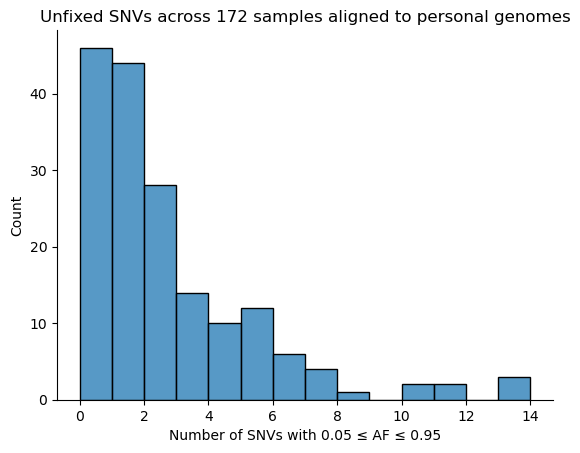

In [255]:
df_plot = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")

sns.histplot(data=df_plot,
             x='NumSNPs',
             bins=np.arange(df_plot.NumSNPs.min(), df_plot.NumSNPs.max() + 1),
            )

plt.title(f"Unfixed SNVs across {df_plot.SampleID.nunique()} samples aligned to personal genomes")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

sns.despine()
plt.savefig("./figures/personal_genome_lowAF_counts_dist.svg", bbox_inches='tight')

In [124]:
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_ground_truth_lowAF_SNPs_summary.query("SameSample==1 & F2 <= @F2_max")['NumSNPs'],
            alternative='two-sided'
           )

KstestResult(statistic=0.01744186046511628, pvalue=0.9999999999999997, statistic_location=3, statistic_sign=1)

In [257]:
min_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.min()
max_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.max()
median_val = df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.median()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")

Min: 0
Max: 14
Median: 1.0


# 4. Compare number of unfixed SNVs between ground truth and H37Rv alignments

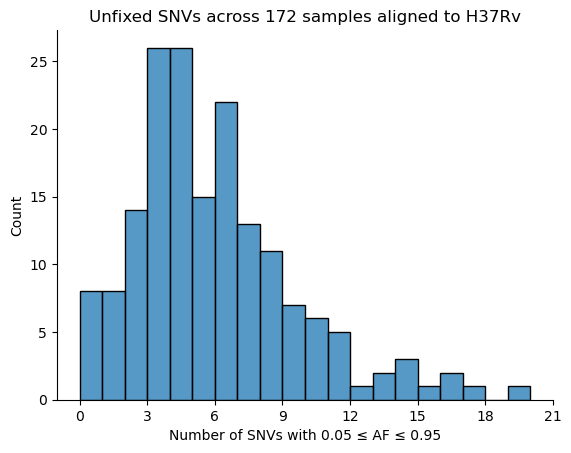

In [132]:
df_plot = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID")
              
sns.histplot(data=df_plot,
             x='NumSNPs',
             bins=np.arange(df_plot.NumSNPs.min(), df_plot.NumSNPs.max() +1),
            )

plt.title(f"Unfixed SNVs across {df_plot.SampleID.nunique()} samples aligned to H37Rv")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

ax = plt.gca()

# Force integer ticks
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

sns.despine()
plt.savefig("./figures/H37Rv_lowAF_counts_initial_dist.svg", bbox_inches='tight')

In [260]:
min_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID").NumSNPs.min()
max_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID").NumSNPs.max()
median_val = df_lowAF_SNPs_summary.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID").NumSNPs.median()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")

Min: 0
Max: 20
Median: 5.0


In [55]:
df_lowAF_SNPs_summary.query("F2 <= @F2_max").NumSNPs.sum()

4331

In [126]:
df_compare_ground_truth_H37Rv = df_ground_truth_lowAF_SNPs_summary.merge(df_lowAF_SNPs_summary.query("F2 <= @F2_max").rename(columns={'NumSNPs': 'NumSNPs_H37Rv', 'NumIndels': 'NumIndels_H37Rv'}), on=['SampleID', 'pid', 'F2'])

df_compare_ground_truth_H37Rv['Difference'] = df_compare_ground_truth_H37Rv['NumSNPs_H37Rv'] - df_compare_ground_truth_H37Rv['NumSNPs']

min_val = df_compare_ground_truth_H37Rv.Difference.min()
max_val = df_compare_ground_truth_H37Rv.Difference.max()
median_val = df_compare_ground_truth_H37Rv.Difference.median()
mean_val = df_compare_ground_truth_H37Rv.Difference.mean()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")
print(f"Mean: {mean_val}")

Min: 0
Max: 19
Median: 3.0
Mean: 3.197674418604651


In [128]:
st.wilcoxon(df_compare_ground_truth_H37Rv['NumSNPs'],
            df_compare_ground_truth_H37Rv['NumSNPs_H37Rv']
           )

WilcoxonResult(statistic=0.0, pvalue=1.1947281148996226e-26)

In [129]:
st.wilcoxon(df_compare_ground_truth_H37Rv['NumSNPs'],
            df_compare_ground_truth_H37Rv['NumSNPs_H37Rv'],
            alternative='less'
           )

WilcoxonResult(statistic=0.0, pvalue=5.973640574498113e-27)

In [131]:
df_compare_ground_truth_H37Rv.NumSNPs.sum(), df_compare_ground_truth_H37Rv.NumSNPs_H37Rv.sum()

(396, 946)

# 5. Number of SNVs before and after LMM 

In [42]:
def read_in_process_variants(model_dir, df_pids, AF_thresh=0.95):
    
    df_fixed_variants = pd.read_csv(f"{model_dir}/fixed_variants.csv.gz", compression='gzip')

    # contains Real or not for the samples with a personal genome
    df_train_variants = pd.read_csv(f"{model_dir}/training_data_with_predictions.csv").query("Real == 1")

    # because of the discordant reads at the end of the linear reference genome, which are not actually discordant, it's just because the circular genome was linearized
    # the binary classifier will predict some low frequency variants at the ends as false because of all the discordantly paired reads there
    # this means that variant upstream of the first position and downstream of the last position can be erroneously flagged as not real
    first_pos = df_train_variants.query("Real==1").POS.min()
    last_pos = df_train_variants.query("Real==1").POS.max()

    # all other samples
    df_val_variants = pd.read_csv(f"{model_dir}/validation_data_with_predictions.csv")
    
    # 4338594 is in the intergenic region between whiB6 and Rv3863. These I verified are real, but sometimes get predicted low quality
    # it was one of the false negatives in the training results, so I'm manually fixing it
    assert 4338594 in df_train_variants.POS.values
    df_val_variants.loc[df_val_variants['POS']==4338594, 'pred_class'] = 1
    
    # exclude fixed SNP sites that had a low quality low frequency variant. Exclude these from the fixed counts too
    for pid in df_val_variants.pid.unique():

        false_lowAF_variant_sites = df_val_variants.query("pid==@pid & pred_class==0 & POS >= @first_pos & POS <= @last_pos & AF <= @AF_thresh").POS.values

        if len(false_lowAF_variant_sites) > 0:
            remove_pos = df_fixed_variants.query("pid==@pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh").POS.unique()
            
#             if len(remove_pos) > 0:
#                 print(pid, len(remove_pos))
            
            df_fixed_variants = df_fixed_variants.query("~(pid == @pid & POS in @false_lowAF_variant_sites & AF > @AF_thresh)")
        
    # only apply the filter for classifier filter to low frequency variants
    df_val_variants = df_val_variants.query("(pred_class == 1 & POS >= @first_pos & POS <= @last_pos) | POS < @first_pos | POS > @last_pos")

    assert len(set(df_train_variants.SampleID).intersection(df_val_variants.SampleID)) == 0
    df_variants = pd.concat([df_train_variants, df_val_variants])

    # set the variants that were False everywhere in the ground truth set to False. These should be flagged as suspicious sites
    df_variants = df_variants.query("False_in_all_Ground_Truth_Samples==0").reset_index(drop=True)
    
    # add in the fixed variants. If Paired_Sample_Num is not in there, it means we took baseline only
    if 'Paired_Sample_Num' not in df_pids.columns:
        df_pids['Paired_Sample_Num'] = 1
        
    df_variants = pd.concat([df_fixed_variants, df_variants]).merge(df_pids[['SampleID', 'Paired_Sample_Num']], on='SampleID')
    
    # drop duplicates because we lowered the AF threshold to 0.9, so if the threshold was higher in the past, then there will be duplicates
    # preferentially keep the one in the fixed variants df
    df_variants = df_variants.drop_duplicates(subset=['SampleID', 'POS', 'REF', 'ALT'], keep='first')

    df_variants['SNP'] = df_variants['POS'].astype(str) + '_' + df_variants['REF'] + '_' + df_variants['ALT']

    df_variants['Region'] = df_variants['POS'].map(h37Rv_coords_dict)

    df_variants.loc[df_variants['Region'].str.contains('NC'), 'Variant_Type'] = 'Intergenic'

    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'REF_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[:3]
    df_variants.loc[~pd.isnull(df_variants['HGVS_P']), 'ALT_AA'] = df_variants.loc[~pd.isnull(df_variants['HGVS_P'])]['HGVS_P'].str.split('p\.').str[-1].str[-3:]

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic'])) & ((df_variants['REF_AA'] == df_variants['ALT_AA']) | (df_variants['ANN'].str.contains('initiator_codon_variant'))), 'Variant_Type'] = 'Silent'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent'])) &
                          (df_variants['HGVS_P'].str.contains('ext*?')), 'Variant_Type'] = 'Stop_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost'])) &
                          (df_variants['HGVS_P'].str.contains('\?')), 'Variant_Type'] = 'Start_Lost'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost'])) & 
                          (df_variants['HGVS_P'].str.contains('\*')), 'Variant_Type'] = 'Nonsense'

    df_variants.loc[(~df_variants['Variant_Type'].isin(['Intergenic', 'Silent', 'Stop_Lost', 'Start_Lost', 'Nonsense'])), 'Variant_Type'] = 'Missense'
    
    # exclude genes Rv2081c and Rv2082. Very problematic for low frequency variant calling. But keep for fixed variants
    df_variants = df_variants.query("~(POS >= 2338065 & POS <= 2340874)")
        
    # return pd.concat([df_fixed_variants, df_variants]), df_variants.drop_duplicates().reset_index(drop=True)
    return df_variants.drop_duplicates().reset_index(drop=True).dropna(axis=1, how='all'), df_variants.query("AF <= @AF_thresh").drop_duplicates().dropna(axis=1, how='all').reset_index(drop=True)

In [43]:
df_variants_baseline, df_lowAF_variants_baseline = read_in_process_variants("../lowAF_variant_calling/variantDetector/unmixed_only", df_trust_patients[['pid', 'SampleID', 'F2', 'Lineage']].dropna())

len(df_variants_baseline), len(df_lowAF_variants_baseline)

(719326, 1779)

In [44]:
len(df_lowAF_variants_baseline.query("F2 <= @F2_max"))

1779

In [45]:
df_lowAF_SNPs_filtered_summary = pd.DataFrame(df_lowAF_variants_baseline.groupby(['pid', 'SampleID', 'F2', 'Lineage'])['POS'].count()).reset_index().rename(columns={'POS': 'NumSNPs'})

samples_no_variants = list(set(df_trust_patients.dropna(subset='Lineage').SampleID) - set(df_lowAF_SNPs_filtered_summary.SampleID))

df_lowAF_SNPs_filtered_summary = pd.concat([df_lowAF_SNPs_filtered_summary,
                                            df_trust_patients.query("SampleID in @samples_no_variants")[['pid', 'SampleID', 'F2', 'Lineage']]
                                           ])

df_lowAF_SNPs_filtered_summary['NumSNPs'] = df_lowAF_SNPs_filtered_summary['NumSNPs'].fillna(0).astype(int)

df_lowAF_SNPs_compare = df_lowAF_SNPs_summary.query("F2 <= @F2_max").rename(columns={'NumSNPs': 'Before'}).merge(df_lowAF_SNPs_filtered_summary.rename(columns={'NumSNPs': 'After'}))

df_lowAF_SNPs_compare['Lineage'] = df_lowAF_SNPs_compare['Lineage'].astype(int).astype(str)
df_lowAF_SNPs_compare['Difference'] = df_lowAF_SNPs_compare['After'] - df_lowAF_SNPs_compare['Before']

print(len(df_lowAF_SNPs_compare))
df_lowAF_SNPs_compare.Lineage.value_counts(dropna=False)

738


Lineage
2    366
4    323
3     48
1      1
Name: count, dtype: int64

In [46]:
min_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.min()
max_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.max()
median_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").Before.median()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")

Min: 0
Max: 30
Median: 5.0


In [47]:
min_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.min()
max_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.max()
median_val = df_lowAF_SNPs_compare.query("F2 <= @F2_max").After.median()

print(f"Min: {min_val}")
print(f"Max: {max_val}")
print(f"Median: {median_val}")

Min: 0
Max: 26
Median: 1.0


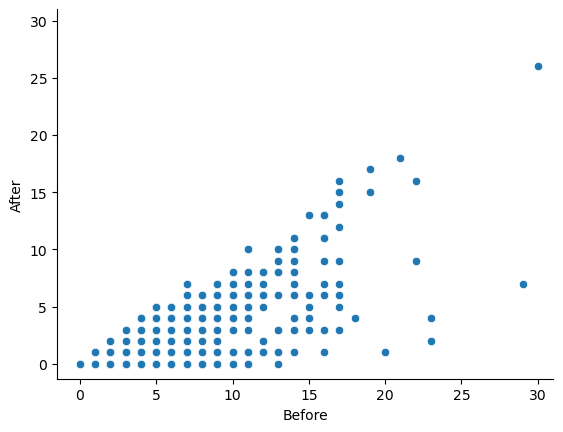

In [48]:
sns.scatterplot(data=df_lowAF_SNPs_compare,
                x='Before',
                y='After'
               )

max_val = df_lowAF_SNPs_compare[['Before', 'After']].max().max()

plt.xlim(right=max_val + 1)
plt.ylim(top=max_val + 1)

sns.despine()

<Axes: xlabel='Difference', ylabel='Proportion'>

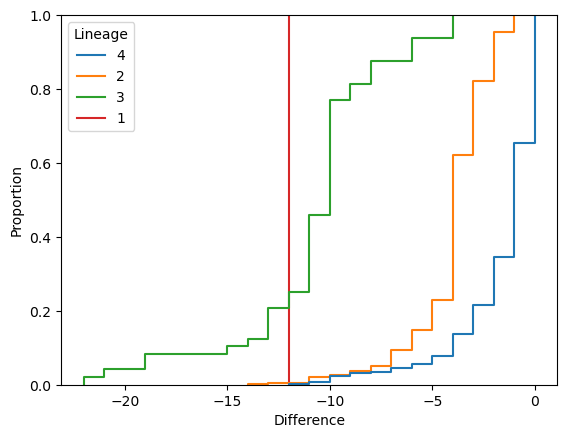

In [49]:
sns.ecdfplot(data=df_lowAF_SNPs_compare,
             x='Difference',
             hue='Lineage',
             # multiple='dodge'
            )

In [50]:
df_lowAF_SNPs_compare.Difference.median(), df_lowAF_SNPs_compare.Difference.mean()

(-3.0, -3.4254742547425474)

In [51]:
df_lowAF_SNPs_compare.Difference.min(), df_lowAF_SNPs_compare.Difference.max()

(-22, 0)

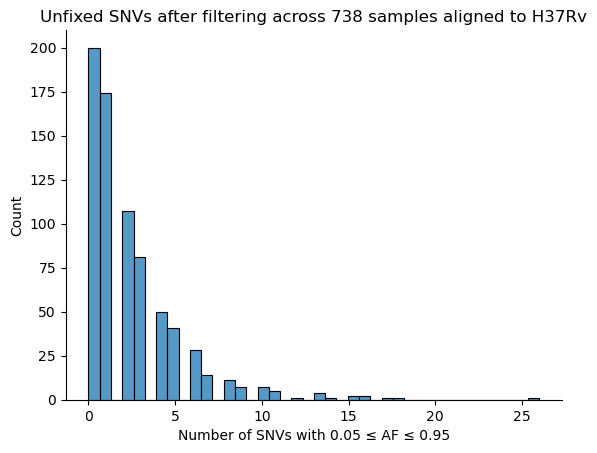

In [52]:
df_plot = df_lowAF_SNPs_compare.query("F2 <= @F2_max")

sns.histplot(data=df_plot,
             x='After'
            )

plt.title(f"Unfixed SNVs after filtering across {df_plot.SampleID.nunique()} samples aligned to H37Rv")
plt.xlabel('Number of SNVs with 0.05 ≤ AF ≤ 0.95')

sns.despine()
plt.savefig("./figures/H37Rv_lowAF_counts_final_dist.svg", bbox_inches='tight')

<Axes: xlabel='After', ylabel='Count'>

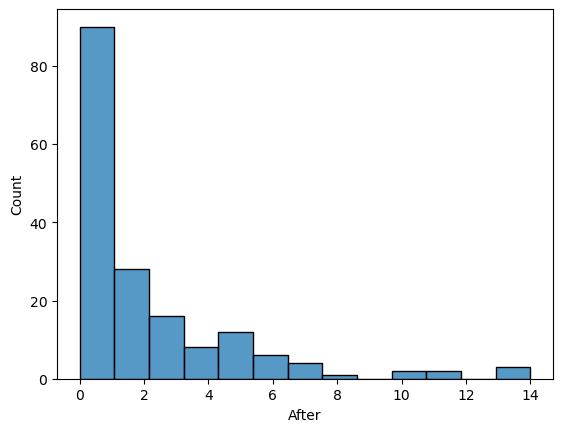

In [53]:
sns.histplot(data=df_lowAF_SNPs_compare.query("F2 <= @F2_max & SampleID in @df_ground_truth_lowAF_SNPs_summary.SampleID"),
             x='After'
            )

In [54]:
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_lowAF_SNPs_compare.query("F2 <= @F2_max")['Before']
           )

KstestResult(statistic=0.45840423520514273, pvalue=4.066227686884914e-27, statistic_location=2, statistic_sign=1)

In [55]:
st.ks_2samp(df_ground_truth_lowAF_SNPs_summary.query("F2 <= @F2_max")['NumSNPs'],
            df_lowAF_SNPs_compare.query("F2 <= @F2_max")['After']
           )

KstestResult(statistic=0.03428499401273082, pvalue=0.9944751589597425, statistic_location=2, statistic_sign=1)

In [80]:
df_lowAF_variants_baseline.GENE.value_counts().head(10)

GENE
sugI       41
Rv2690c    19
devS       18
devR       18
phoR       15
Rv0193c    11
Rv2781c    11
subI       10
Rv0273c     9
gcvB        9
Name: count, dtype: int64

In [83]:
pd.DataFrame(df_lowAF_variants_baseline.GENE.value_counts()).loc['phoP']

count    2
Name: phoP, dtype: int64

In [85]:
df_lowAF_variants_baseline.query("GENE=='phoP'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Real,False_in_all_Ground_Truth_Samples,predicted,pred_class,Paired_Sample_Num,SNP,Region,Variant_Type,REF_AA,ALT_AA
672,851982,G,T,4.500000e+03,phoP,c.375G>T,p.Leu125Phe,1,301,301.0,...,NaN,0.0,0.998417,1.0,1,851982_G_T,phoP,Missense,Leu,Phe
707,851731,T,C,1.100000e-14,phoP,c.124T>C,p.Phe42Leu,1,274,274.0,...,NaN,0.0,0.999173,1.0,1,851731_T_C,phoP,Missense,Phe,Leu


In [92]:
df_lowAF_variants_baseline.query("POS >= 851466 & POS <= 852351").pid.unique()

array(['T0341', 'T0352'], dtype=object)

In [75]:
for gene in df_lowAF_variants_baseline.GENE.value_counts().index.values[:5]:
    print(gene, np.sort(df_lowAF_variants_baseline.query("GENE==@gene")['Lineage'].unique()))

sugI [2. 3. 4.]
Rv2690c [2. 4.]
devS [2. 3. 4.]
devR [2. 3. 4.]
phoR [2. 4.]


In [61]:
df_lowAF_variants_baseline.SNP.value_counts()

SNP
3717105_C_T    17
226517_C_T     10
329923_T_C      9
1208652_G_A     9
93313_C_T       8
               ..
2154800_A_G     1
2153995_G_T     1
1955265_C_G     1
3596606_T_C     1
1844169_G_T     1
Name: count, Length: 1476, dtype: int64

In [68]:
df_lowAF_variants_baseline.dropna(subset='HGVS_P').query("HGVS_P.str.contains('p.Pro7') & GENE=='sugI'")

,POS,REF,ALT,QUAL,GENE,HGVS_C,HGVS_P,NS,DP,DPB,...,Real,False_in_all_Ground_Truth_Samples,predicted,pred_class,Paired_Sample_Num,SNP,Region,Variant_Type,REF_AA,ALT_AA
41,3717108,C,A,3.400000e+03,sugI,c.19C>A,p.Pro7Thr,1,259,259.0,...,1.0,0.0,0.997928,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
72,3717108,C,A,3.700000e+03,sugI,c.19C>A,p.Pro7Thr,1,299,299.0,...,1.0,0.0,0.974929,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
195,3717108,C,A,0.000000e+00,sugI,c.19C>A,p.Pro7Thr,1,338,338.0,...,NaN,0.0,0.995780,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
561,3717109,C,A,1.700000e+03,sugI,c.20C>A,p.Pro7His,1,258,258.0,...,NaN,0.0,0.993289,1.0,1,3717109_C_A,sugI,Missense,Pro,His
736,3717108,C,A,7.000000e-14,sugI,c.19C>A,p.Pro7Thr,1,227,227.0,...,NaN,0.0,0.980904,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
789,3717109,C,A,2.200000e-13,sugI,c.20C>A,p.Pro7His,1,291,291.0,...,NaN,0.0,0.997672,1.0,1,3717109_C_A,sugI,Missense,Pro,His
924,3717108,C,A,9.200000e-15,sugI,c.19C>A,p.Pro7Thr,1,218,218.0,...,NaN,0.0,0.997916,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr
1369,3717109,C,A,4.500000e-14,sugI,c.20C>A,p.Pro7His,1,273,273.0,...,NaN,0.0,0.999715,1.0,1,3717109_C_A,sugI,Missense,Pro,His
1451,3717109,C,A,1.700000e-13,sugI,c.20C>A,p.Pro7His,1,425,425.0,...,NaN,0.0,0.999958,1.0,1,3717109_C_A,sugI,Missense,Pro,His
1716,3717108,C,A,6.800000e+01,sugI,c.19C>A,p.Pro7Thr,1,285,285.0,...,NaN,0.0,0.999266,1.0,1,3717108_C_A,sugI,Missense,Pro,Thr


# 5. How many Ground Truth Variants could not be Transferred to H37Rv Coordinates?

Those in IS6110 elements will not be able to be transferred, so leave as is. 

Right now, there is one real variant that could not be transferred: 3717219 (sugI) in MFS-160. I don't know why it wasn't transferred. 

But there is no longitudinal sampling for this pid, so it's not a huge deal, and it's detected when aligning Illumina reads to H37Rv and the LMM predicts it as a real variant, so the signal is good. paftools.js liftover just fails.

In [132]:
def get_id_from_gtf_attribute(attr_string):
    """
    Extract the value of the ID field from a GTF/GFF attributes string.

    Example:
    attr_string = "ID=gene-Rv3324c;Dbxref=GeneID:887981;Name=moaC3;..."
    returns "gene-Rv3324c"
    """
    # Split by semicolon
    fields = attr_string.split(";")
    
    # Iterate through key=value pairs
    for f in fields:
        f = f.strip()
        if f.startswith("ID="):
            return f.split("=", 1)[1]  # split only on first '='
    
    # If no ID field found, return None
    return None

In [133]:
df_transferred_variants = pd.DataFrame(columns = ['SampleID', 'NumSNPs', 'NumSNPsTransferred'])

for i, sample in enumerate(os.listdir(personal_ref_dir)):
    
    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t').query("REF.str.len() == ALT.str.len()").drop_duplicates(subset=['POS', 'REF', 'ALT'])

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])
    
    if len(H37Rv_transferred_variants) > 0:
        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)
        
        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)
    else:
        num_transferred = 0
            
    df_transferred_variants.loc[i, :] = [sample, len(personal_genome_variants), num_transferred]
    
df_transferred_variants = df_transferred_variants.merge(df_trust_patients[['pid', 'SampleID', 'F2', 'Coll2014']], on='SampleID', how='left')
assert sum(pd.isnull(df_transferred_variants['pid'])) == 0

In [134]:
search_samples = df_transferred_variants.query("F2 <= @F2_max & NumSNPs != NumSNPsTransferred").SampleID.values

for sample in search_samples:

    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t')#.query("REF.str.len() == ALT.str.len()")

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])

    if len(H37Rv_transferred_variants) > 0:

        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)

        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)

        missed_pos = list(set(personal_genome_variants.POS) - set(combined_variants.POS))

        # see if the variant was found when aligning to H37Rv. If it was, then we have a problem that we can fix. If it wasn't, then the region is just too different for paftools liftover to transfer it
        df_H37Rv_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/lowAF_SNPs.csv")
        
        liftoff_gtf = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff_polished", sep='\t', header=None, comment='#',
                                  names=['Chrom', 'Source', 'Feature', 'Start', 'End', 'Score', 'Sense', 'Score2', 'Attribute']
                                 )
        
#         df_IS6110_elements = pd.read_csv(f"{personal_ref_dir}/{sample}/IS6110/{sample}.sam", header=None, sep='\t')
        
#         IS6110_pos = []
        
#         # IS6110 element is 1,355 bp long
#         for i, row in df_IS6110_elements.iterrows():
#             IS6110_pos += list(np.arange(row[3], row[3] + 1355))

        for pos in missed_pos:
            # min_distance = np.min(np.abs(np.array([pos]) - np.array(IS6110_pos)))
            AF = personal_genome_variants.query("POS==@pos").get('AF').values[0]
            # print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)} within {min_distance} bp of an IS6110 element")
            print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)}")
            
            within_gene = liftoff_gtf.query("Feature=='gene' & Start <= @pos & End >= @pos")
            
            if len(within_gene) > 0:
                gene = get_id_from_gtf_attribute(within_gene.Attribute.values[-1]).split('-')[-1]
                print(f"    Within {gene}")
            else:
                upstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("Feature=='gene' & Start <= @pos").Attribute.values[-1]).split('-')[-1]
                downstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("End >= @pos").Attribute.values[0]).split('-')[-1]
                print(f"    {upstream_gene}-{downstream_gene}")

MFS-160 has a missed position, 3725173 with AF = 0.1342
    Within Rv3331
MFS-26 has a missed position, 3719445 with AF = 0.244
    Rv3324c-Rv3327
MFS-321 has a missed position, 3711316 with AF = 0.3899
    Rv3324c-Rv3327
MFS-322 has a missed position, 3711316 with AF = 0.4315
    Rv3324c-Rv3327
MFS-4 has a missed position, 3708237 with AF = 0.2005
    Rv3324c-Rv3327


# F2 for Longitudinal Samples

In [133]:
df_longitudinal_pids_init = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids_init.pid.nunique()} pids")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids_init.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids_init.groupby('pid')['Coll2014'].nunique()).query("Coll2014 == 1").index.values
pids_with_same_lineage = set(pids_with_same_lineage).intersection(pd.DataFrame(df_longitudinal_pids_init.groupby('pid')['Freschi2020'].nunique()).query("Freschi2020 == 1").index.values)
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

print(f"{len(pids_with_same_lineage)}/{df_longitudinal_pids_init.pid.nunique()} pids have the same lineage assigned to both samples")

include_pids_consistent_mixed_lineages = []

for pid in df_longitudinal_pids_init.query("pid not in @pids_with_same_lineage and pid not in @pids_with_low_F2").pid.unique():
    
    lineage_1, lineage_2 = df_longitudinal_pids_init.query("pid==@pid").Coll2014.unique()
    
    lineage_1 = lineage_1.split(',')
    lineage_2 = lineage_2.split(',')
    
    if len(set(lineage_1).intersection(lineage_2)) > 0:
        include_pids_consistent_mixed_lineages.append(pid)

candidate_mixed_pids = df_longitudinal_pids_init.query("pid not in @pids_with_low_F2").pid.unique()

check_fastlin_samples = list(set(candidate_mixed_pids) - set(include_pids_consistent_mixed_lineages))

for pid in check_fastlin_samples:
    
    samples = df_longitudinal_pids_init.query("pid==@pid").SampleID.values
    assert len(samples) == 2
    
    fastlin_1 = pd.read_csv(f"{H37Rv_ref_dir}/{samples[0]}/{samples[0]}/fastlin/output.txt", sep='\t')
    fastlin_2 = pd.read_csv(f"{H37Rv_ref_dir}/{samples[1]}/{samples[1]}/fastlin/output.txt", sep='\t')
    
    sample_1_lineages = fastlin_1['lineages'].values[0].split(',')
    sample_1_lineages = [lineage.split(' (')[0].strip() for lineage in sample_1_lineages]
        
    sample_2_lineages = fastlin_2['lineages'].values[0].split(',')
    sample_2_lineages = [lineage.split(' (')[0].strip() for lineage in sample_2_lineages]
         
    if len(set(sample_1_lineages).intersection(sample_2_lineages)) > 0:
        include_pids_consistent_mixed_lineages.append(pid)
    else:
        print(f"    {pid} does not have consistent mixing: {sample_1_lineages}, {sample_2_lineages}")
        
print(f"{len(include_pids_consistent_mixed_lineages)} pids with mixed lineages have consistent mixing")
        
df_longitudinal_pids = df_longitudinal_pids_init.query("pid in @pids_with_same_lineage | pid in @include_pids_consistent_mixed_lineages").reset_index(drop=True)
print(f"{df_longitudinal_pids.pid.nunique()} pids remaining for analysis")

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")

315 pids
293/315 pids have the same lineage assigned to both samples
    T0364 does not have consistent mixing: ['2.2.1.1'], ['2.2.1']
21 pids with mixed lineages have consistent mixing
307 pids remaining for analysis
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    Sampling interval: median = 6.0, mean = 5.501628664495114


In [134]:
df_longitudinal_pids['Major_Lineage'] = np.nan
df_longitudinal_pids['Major_Lineage_Prop'] = np.nan
df_longitudinal_pids['Minor_Lineage'] = np.nan
df_longitudinal_pids['Minor_Lineage_Prop'] = np.nan

for i, row in df_longitudinal_pids.iterrows():
    
    pid = row['pid']
    sample = row['SampleID']
    
    fastlin_file = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/{sample}/fastlin/output.txt", sep='\t')

    estimated_cov = fastlin_file['k_cov'].values[0]
    
    fastlin_split = fastlin_file['lineages'].values[0].split(',')
    fastlin_lineages = [lineage.split(' (')[0].strip() for lineage in fastlin_split]
    fastlin_kmer_counts = [int(lineage.split(' (')[1].split(')')[0]) for lineage in fastlin_split]

    fastlin_results = dict(zip(fastlin_lineages, fastlin_kmer_counts))

    df_longitudinal_pids.loc[i, 'Major_Lineage'] = fastlin_lineages[np.argmax(fastlin_kmer_counts)]
    df_longitudinal_pids.loc[i, 'Major_Lineage_Prop'] = np.max(fastlin_kmer_counts) / estimated_cov
    
    if len(fastlin_lineages) > 1:
        # print(fastlin_lineages)
        
        second_highest_idx = np.argpartition(fastlin_kmer_counts, -2)[-2]
        
        df_longitudinal_pids.loc[i, 'Minor_Lineage'] = fastlin_lineages[second_highest_idx]
        df_longitudinal_pids.loc[i, 'Minor_Lineage_Prop'] = fastlin_kmer_counts[second_highest_idx] / estimated_cov

df_longitudinal_pids['Major_Lineage'] = df_longitudinal_pids['Major_Lineage'].fillna(df_longitudinal_pids['Coll2014'])
df_longitudinal_pids['Major_Lineage_Prop'] = df_longitudinal_pids['Major_Lineage_Prop'].fillna(1)

In [135]:
same_lineages = []

pids_multiple_lineages = df_longitudinal_pids.query("F2 > @F2_max").pid.unique()

for pid in pids_multiple_lineages:
    
    sample_1_major_lineage = df_longitudinal_pids.query("pid == @pid & Paired_Sample_Num == 1").Major_Lineage.values[0]
    sample_2_major_lineage = df_longitudinal_pids.query("pid == @pid & Paired_Sample_Num == 2").Major_Lineage.values[0]
    
    if sample_1_major_lineage == sample_2_major_lineage:
        same_lineages.append(pid)

len(same_lineages), len(pids_multiple_lineages)

(15, 22)

<Axes: xlabel='F2', ylabel='Count'>

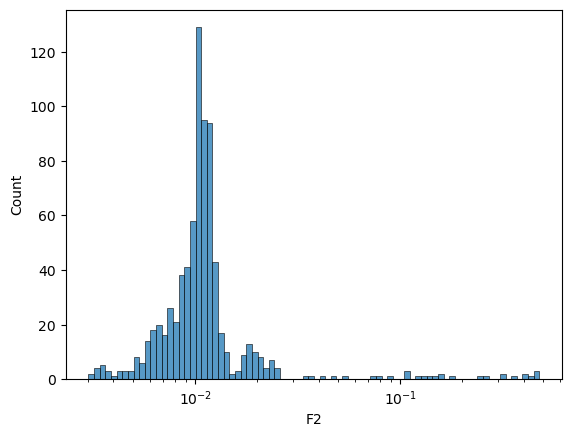

In [136]:
sns.histplot(data=df_trust_patients,
             x='F2',
             log_scale=10
            )



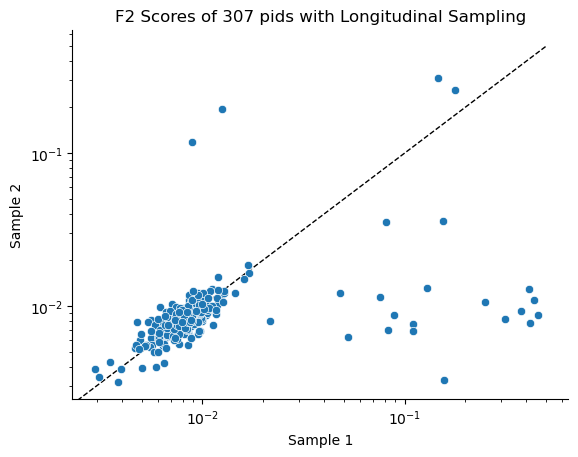

In [137]:
df_F2_longitudinal = df_longitudinal_pids.pivot(index='pid', columns='Paired_Sample_Num', values='F2').reset_index()
df_F2_longitudinal.columns = ['pid', 'Sample1', 'Sample2']
df_F2_longitudinal['F2_Diff'] = df_F2_longitudinal['Sample2'] - df_F2_longitudinal['Sample1']
df_F2_longitudinal['Abs_F2_Diff'] = np.abs(df_F2_longitudinal['F2_Diff'])

sns.scatterplot(data=df_F2_longitudinal,
                x='Sample1',
                y='Sample2',
               )

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Sample 1')
plt.ylabel('Sample 2')
plt.title(f'F2 Scores of {df_longitudinal_pids.pid.nunique()} pids with Longitudinal Sampling')

x_vals = np.linspace(0, 0.5, 10)
plt.plot(x_vals, x_vals, color='black', zorder=0, linestyle='--', linewidth=1)

sns.despine()
plt.savefig("./figures/F2_longitudinal.svg", bbox_inches='tight')

In [138]:
pids_high_F2_both = df_F2_longitudinal.query("Sample1 > 0.1 & Sample2 > 0.1").pid.unique()

df_longitudinal_pids.query("pid in @pids_high_F2_both")

,pid,Original_ID,SampleID,Sampling_Week,screen_prevpid,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples,Sampling_Interval,Major_Lineage,Major_Lineage_Prop,Minor_Lineage,Minor_Lineage_Prop
216,T0167,S0167-01,MFS-84,1,NaN,2.2.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,asian_african_2",NaN,0.178420,2,1,2,3,2.2.1,0.741538,4.1.1.3,0.163077
217,T0167,S0167-04,MFS-85,4,NaN,"2.2.1,4.1.1.3","4.1,2.2.1.1.1","beijing,xtype,mungi","lin2.2.1,asian_african_2",NaN,0.259553,"2,4",2,2,3,2.2.1,0.731861,4.1.1.3,0.233438
268,T0204,S0204-01,MFS-630,1,NaN,2.2.1,2.2.1.1.1,"beijing,east_african_indian,mungi",lin2.2.1,NaN,0.145586,2,1,2,7,2.2.1,0.795796,3.1.1,0.126126
269,T0204,S0204-08,MFS-631,8,NaN,"2.2.1,3","2.2.1.1.1,3.1.1.i1","beijing,east_african_indian,mungi",lin2.2.1,NaN,0.308594,"2,3",2,2,7,2.2.1,0.632411,3.1.1,0.252964


In [139]:
df_trust_patients.query("Original_ID.str.contains('m', case=False)")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
14,T0272,S0272-M5,MFS-881,MFS-881_lib84073,NaN,NaN,1.0,349.33,0.99,0.9725,...,NaN,NaN,3.0,0.879111,1.0,0.007258,2.2.1,2.2.1.1.1,2,20
15,T0272,S0272-m5,MFS-653,MFS-653_lib66334,NaN,NaN,1.0,92.81,0.99,0.3655,...,NaN,NaN,3.0,0.879111,1.0,NaN,NaN,NaN,NaN,20
62,T0410,S0410-PM12,MFS-889,MFS-889_lib83844,NaN,NaN,1.0,290.19,0.99,0.9761,...,NaN,NaN,1.0,0.407299,1.0,0.009126,4.3.3,4.2.1.2.1.1.i4.1,4,72
393,T0204,S0204-m5,MFS-632,MFS-632_lib66025,NaN,NaN,1.0,309.10,0.99,0.9833,...,NaN,NaN,2.0,0.238897,NaN,0.008530,2.2.1,2.2.1.1.1,2,20
422,T0330,S0330-m5,MFS-660,MFS-660_lib66341,NaN,NaN,1.0,328.60,0.99,0.9830,...,NaN,NaN,1.0,0.259194,1.0,0.006470,4.1.1.1,4.1.i1.2.1,4,20


In [140]:
pids_increase_F2 = df_F2_longitudinal.query("Sample2 > Sample1 & Sample2 > 0.1 & Sample1 < 0.1").pid.unique()

df_longitudinal_pids.query("pid in @pids_increase_F2")

,pid,Original_ID,SampleID,Sampling_Week,screen_prevpid,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,Paired_Sample_Num,total_samples,Sampling_Interval,Major_Lineage,Major_Lineage_Prop,Minor_Lineage,Minor_Lineage_Prop
294,T0224,S0224-01,MFS-133,1,NaN,2.2.1,2.2.1.1.1,"beijing,mungi",lin2.2.1,NaN,0.012427,2,1,2,7,2.2.1.1,0.018750,NaN,NaN
295,T0224,S0224-08,MFS-134,8,NaN,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.193040,2,2,2,7,2.2.1.1,0.603571,NaN,NaN
306,T0235,S0235-01,MFS-144,1,NaN,2.2.1.1,2.2.1.1.1,"beijing,mungi","lin2.2.1,pacific_RD150",NaN,0.008906,2,1,2,4,2.2.1.1,1.002309,NaN,NaN
307,T0235,S0235-05,MFS-145,5,NaN,4.8,4.2.1.1.1.1.1.1.i1,"beijing,canetti",NaN,4.10/PGG3,0.118415,4,2,2,4,4.8,0.788321,2.2.1.1,0.099757


In [108]:
pids_decrease_F2

array(['T0010', 'T0066', 'T0072', 'T0087', 'T0116', 'T0152', 'T0198',
       'T0267', 'T0305', 'T0311', 'T0322', 'T0364', 'T0367', 'T0393',
       'T0427', 'T0441', 'T0444', 'T0457'], dtype=object)

In [125]:
pids_decrease_F2 = df_F2_longitudinal.query("Sample1 > Sample2 & Sample1 > @F2_max").pid.unique()

major_lineage_remaining_FU = []

for pid in pids_decrease_F2:
    
    major_lineage_1 = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').Major_Lineage.values[0]
    major_lineage_2 = df_longitudinal_pids.query("pid==@pid").sort_values('Sampling_Week').Major_Lineage.values[-1]
    
    if major_lineage_1 == major_lineage_2:
        major_lineage_remaining_FU.append(pid)
        
len(major_lineage_remaining_FU), len(pids_decrease_F2)

(12, 18)

In [132]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid not in @major_lineage_remaining_FU")[['pid', 'SampleID', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage_Prop.mean()

0.7974888615153087

In [140]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid not in @major_lineage_remaining_FU")[['pid', 'SampleID', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage.value_counts()

Major_Lineage
2.2.1.1      3
4.1.2.1      1
4.3.3        1
4.3.4.2.1    1
Name: count, dtype: int64

In [136]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid in @major_lineage_remaining_FU")[['pid', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage_Prop.mean()

0.783450373857154

In [139]:
df_longitudinal_pids.query("pid in @pids_decrease_F2 & pid in @major_lineage_remaining_FU")[['pid', 'Sampling_Week', 'Coll2014', 'F2', 'Major_Lineage', 'Major_Lineage_Prop', 'Minor_Lineage', 'Minor_Lineage_Prop']].drop_duplicates('pid', keep='first').Major_Lineage.value_counts()

Major_Lineage
2.2.1.1    9
4.1.2.1    1
4.3.2.1    1
4.1.1.3    1
Name: count, dtype: int64